In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')from pmdarima import auto_arima

/kaggle/input/datasets/jharilova/dataset-sentiment/3) Sentiment dataset.csv


In [20]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/jharilova/dataset-sentiment/3) Sentiment dataset.csv


In [21]:
pip install pmdarima



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
from pmdarima import auto_arima

In [23]:
# load the dataset
df = pd.read_csv("/kaggle/input/datasets/jharilova/dataset-sentiment/3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [24]:
# convert to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

#create time series : count of post per hour
df["Timestamp"]= pd.to_datetime(df["Timestamp"])

# Create time seeries : count of post per hour
df.set_index("Timestamp", inplace = True)
hourly_posts = df.resample("h").size()
hourly_posts = hourly_posts.fillna(0)

print(f"Dataset shape{hourly_posts.shape}")
print(f"Date range: {hourly_posts.index[0]} to {hourly_posts.index[-1]}")
print(f"\nFirst 10 observations:\n{hourly_posts.head(10)}")
print(f"\nBasic statistics:\n{hourly_posts.describe()}")

Dataset shape(117798,)
Date range: 2010-05-15 15:00:00 to 2023-10-22 20:00:00

First 10 observations:
Timestamp
2010-05-15 15:00:00    1
2010-05-15 16:00:00    0
2010-05-15 17:00:00    0
2010-05-15 18:00:00    0
2010-05-15 19:00:00    0
2010-05-15 20:00:00    0
2010-05-15 21:00:00    0
2010-05-15 22:00:00    0
2010-05-15 23:00:00    0
2010-05-16 00:00:00    0
Freq: h, dtype: int64

Basic statistics:
count    117798.000000
mean          0.006214
std           0.085218
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
dtype: float64


# Exploratory Data Analysis

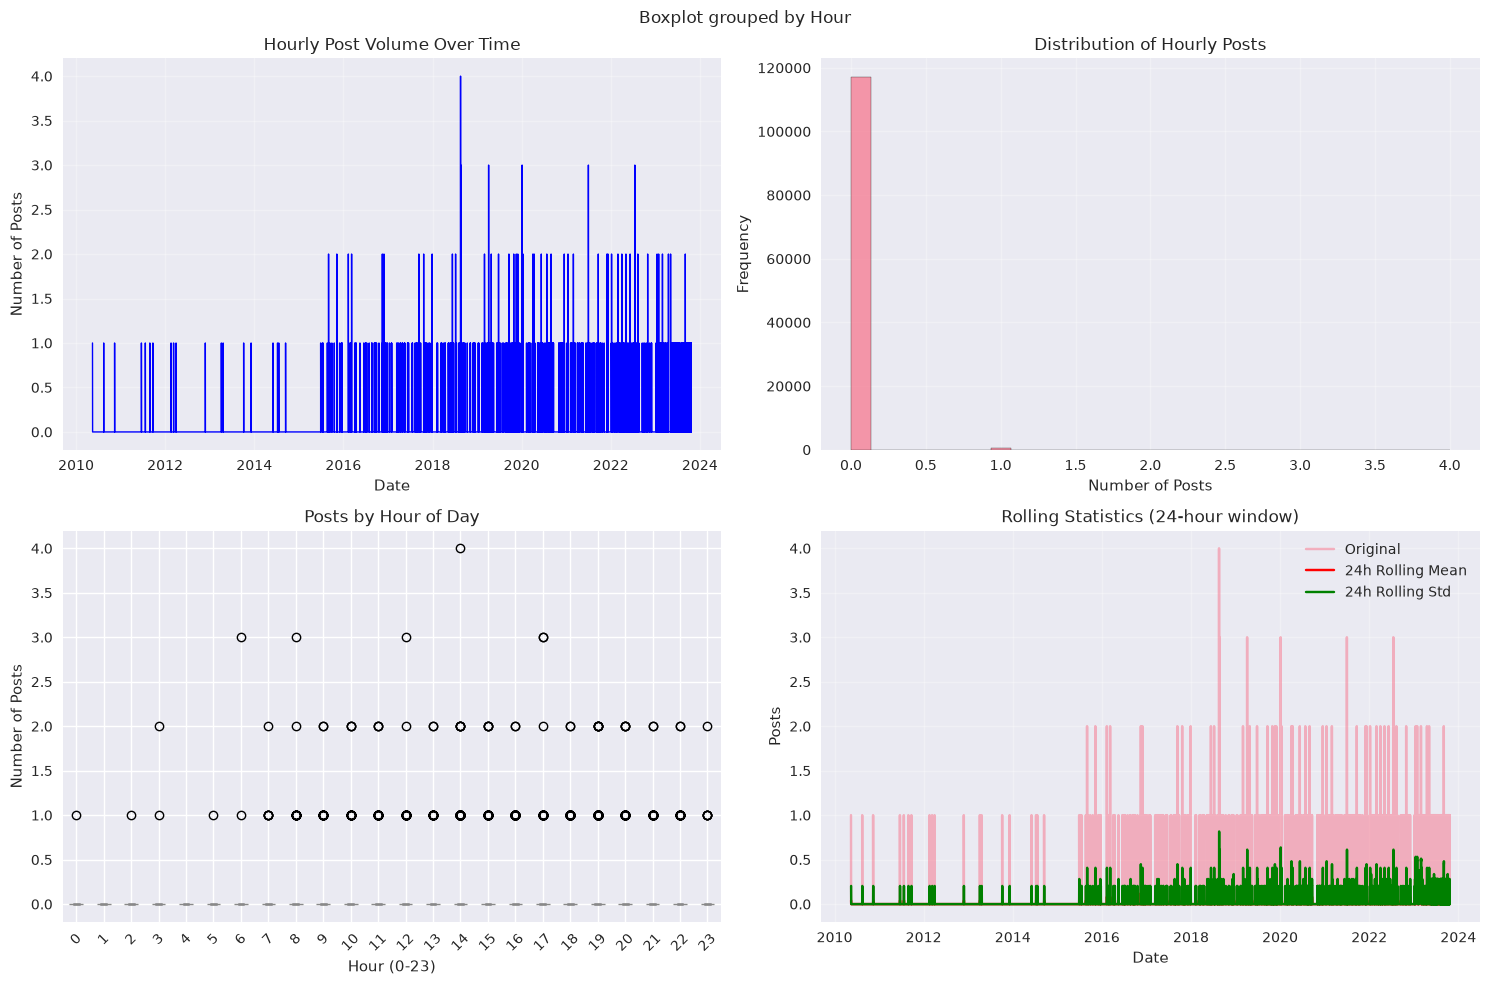

In [25]:
# Plot the time series
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Line plot
axes[0,0].plot(hourly_posts.index, hourly_posts.values, color='blue', linewidth=1)
axes[0,0].set_title('Hourly Post Volume Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Number of Posts')
axes[0,0].grid(True, alpha=0.3)

# Distribution
axes[0,1].hist(hourly_posts, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribution of Hourly Posts')
axes[0,1].set_xlabel('Number of Posts')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Boxplot by hour of day - CORRECTED VERSION
hour_of_day = hourly_posts.index.hour
# Create a DataFrame with hour and post count for boxplot
boxplot_data = pd.DataFrame({'Hour': hour_of_day, 'Posts': hourly_posts.values})
# Boxplot using pandas plot method
boxplot_data.boxplot(column='Posts', by='Hour', ax=axes[1,0], grid=True)
axes[1,0].set_title('Posts by Hour of Day')
axes[1,0].set_xlabel('Hour (0-23)')
axes[1,0].set_ylabel('Number of Posts')
plt.setp(axes[1,0].get_xticklabels(), rotation=45)

# Rolling statistics
rolling_mean = hourly_posts.rolling(window=24).mean()
rolling_std = hourly_posts.rolling(window=24).std()
axes[1,1].plot(hourly_posts.index, hourly_posts, alpha=0.5, label='Original')
axes[1,1].plot(hourly_posts.index, rolling_mean, color='red', label='24h Rolling Mean')
axes[1,1].plot(hourly_posts.index, rolling_std, color='green', label='24h Rolling Std')
axes[1,1].set_title('Rolling Statistics (24-hour window)')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Posts')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Time serie decomposition

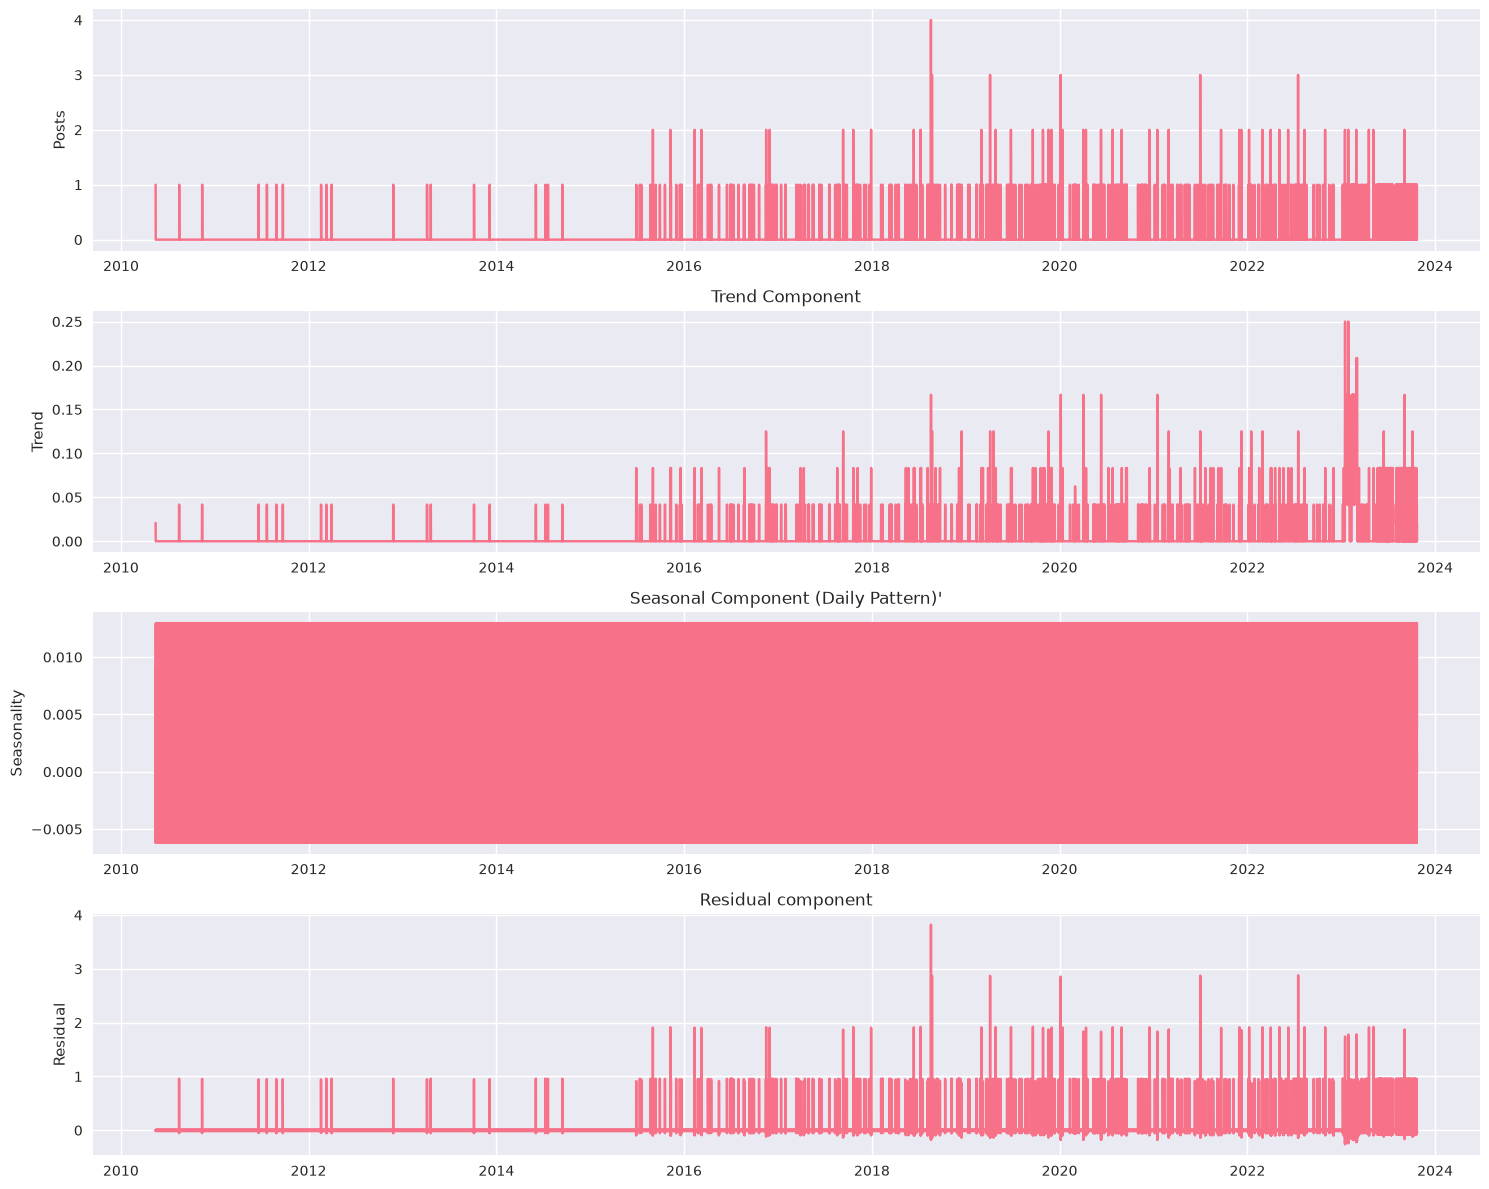

DECOMPOSITION INSIGHTS:
Trend direction: Decreasing
Seasonality strength: 0.004


In [26]:
# Decompose into trend, seasonality, and residual
# Use period=24 for daily seasonality (24 hours)
decomposition = seasonal_decompose(hourly_posts, model = "additive", period = 24)

# Plot decomposition
fig, axes = plt.subplots(4,1, figsize = (15,12))
axes[0].plot(decomposition.observed)
axes[0].set_ylabel('Posts')

axes[1].plot(decomposition.trend)
axes[1].set_title("Trend Component")
axes[1].set_ylabel("Trend")

axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonal Component (Daily Pattern)'")
axes[2].set_ylabel("Seasonality")

axes[3].plot(decomposition.resid)
axes[3].set_title("Residual component")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel

plt.tight_layout()
plt.show()


# Print decomposition insights
print("DECOMPOSITION INSIGHTS:")
print(f"Trend direction: {'Increasing' if decomposition.trend.iloc[-1] > decomposition.trend.iloc[0] else 'Decreasing'}")
print(f"Seasonality strength: {1 - decomposition.resid.var() / (decomposition.seasonal.var() + decomposition.resid.var()):.3f}")

# Moving average techniques

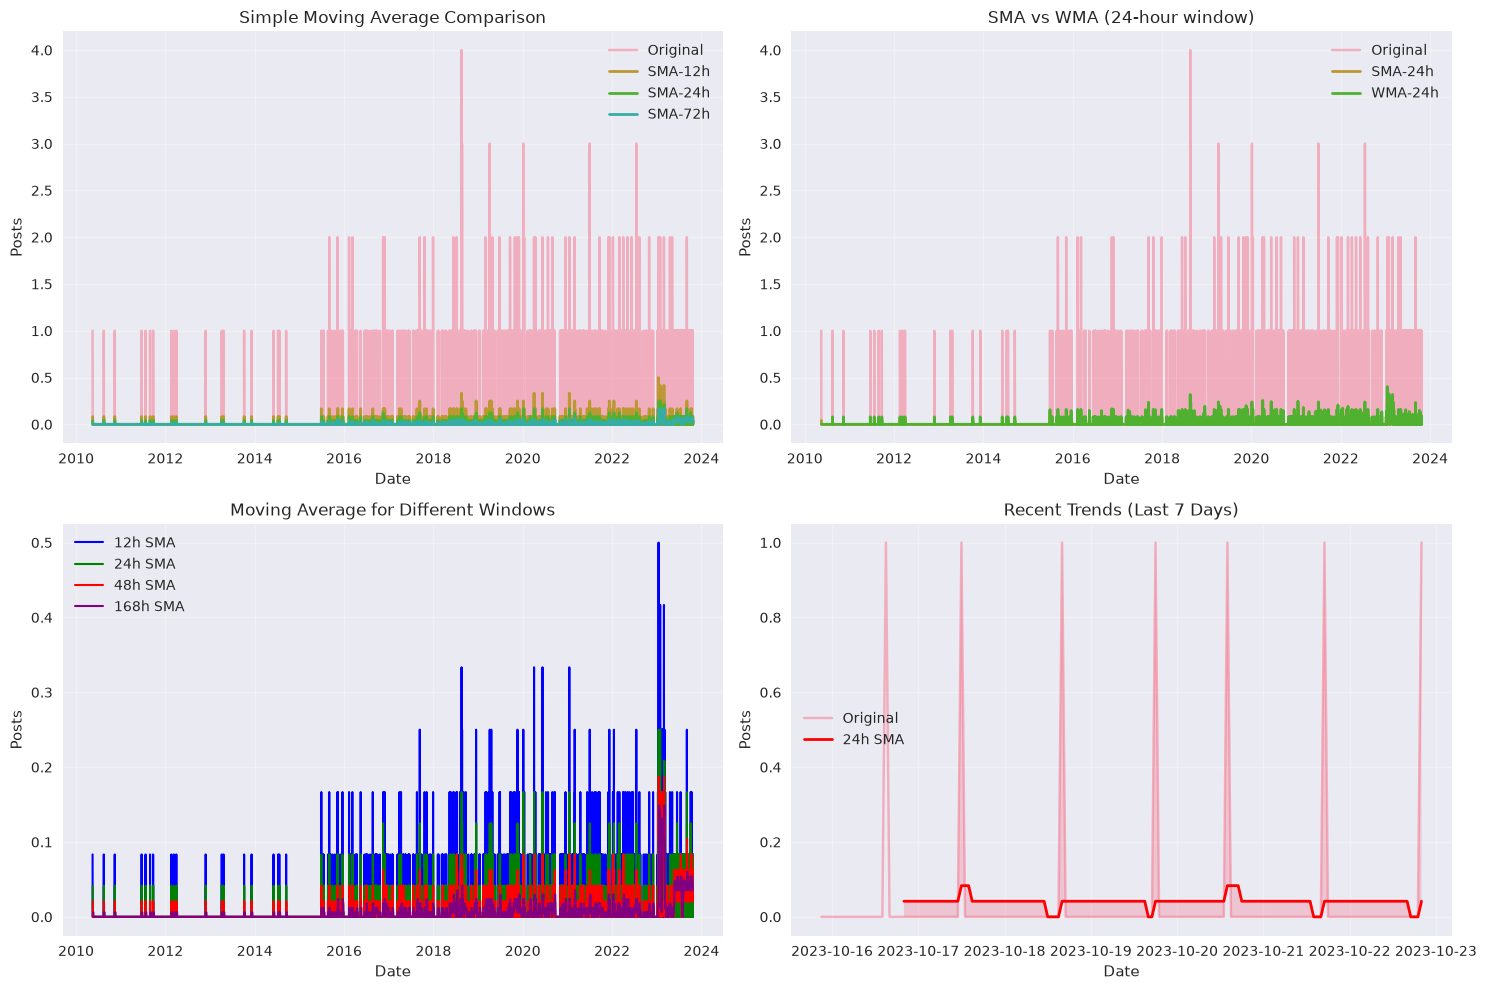

In [27]:
# Implement different moving averages
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Simple Moving Average (SMA)
sma_12 = hourly_posts.rolling(window=12).mean()
sma_24 = hourly_posts.rolling(window=24).mean()
sma_72 = hourly_posts.rolling(window=72).mean()

axes[0,0].plot(hourly_posts.index, hourly_posts, alpha=0.5, label='Original')
axes[0,0].plot(hourly_posts.index, sma_12, label='SMA-12h', linewidth=2)
axes[0,0].plot(hourly_posts.index, sma_24, label='SMA-24h', linewidth=2)
axes[0,0].plot(hourly_posts.index, sma_72, label='SMA-72h', linewidth=2)
axes[0,0].set_title('Simple Moving Average Comparison')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Posts')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Weighted Moving Average
def weighted_ma(data, window):
    weights = np.arange(1, window + 1)
    weights = weights / weights.sum()
    return data.rolling(window).apply(lambda x: np.dot(x, weights), raw=True)

wma_24 = weighted_ma(hourly_posts, 24)

axes[0,1].plot(hourly_posts.index, hourly_posts, alpha=0.5, label='Original')
axes[0,1].plot(hourly_posts.index, sma_24, label='SMA-24h', linewidth=2)
axes[0,1].plot(hourly_posts.index, wma_24, label='WMA-24h', linewidth=2)
axes[0,1].set_title('SMA vs WMA (24-hour window)')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Posts')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Impact of different window sizes
for window, color in [(12, 'blue'), (24, 'green'), (48, 'red'), (168, 'purple')]:
    sma = hourly_posts.rolling(window=window).mean()
    axes[1,0].plot(hourly_posts.index, sma, label=f'{window}h SMA', color=color, linewidth=1.5)
axes[1,0].set_title('Moving Average for Different Windows')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Posts')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Recent trends visualization
last_week = hourly_posts.tail(168)  # Last 7 days
sma_24_week = last_week.rolling(24).mean()
axes[1,1].plot(last_week.index, last_week, alpha=0.5, label='Original')
axes[1,1].plot(last_week.index, sma_24_week, color='red', linewidth=2, label='24h SMA')
axes[1,1].fill_between(last_week.index, last_week, sma_24_week, alpha=0.3)
axes[1,1].set_title('Recent Trends (Last 7 Days)')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Posts')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exponential smoothing

Training data: 117630 hours
Testing data: 168 hours
Training data has 116961 zero values
Testing data has 161 zero values


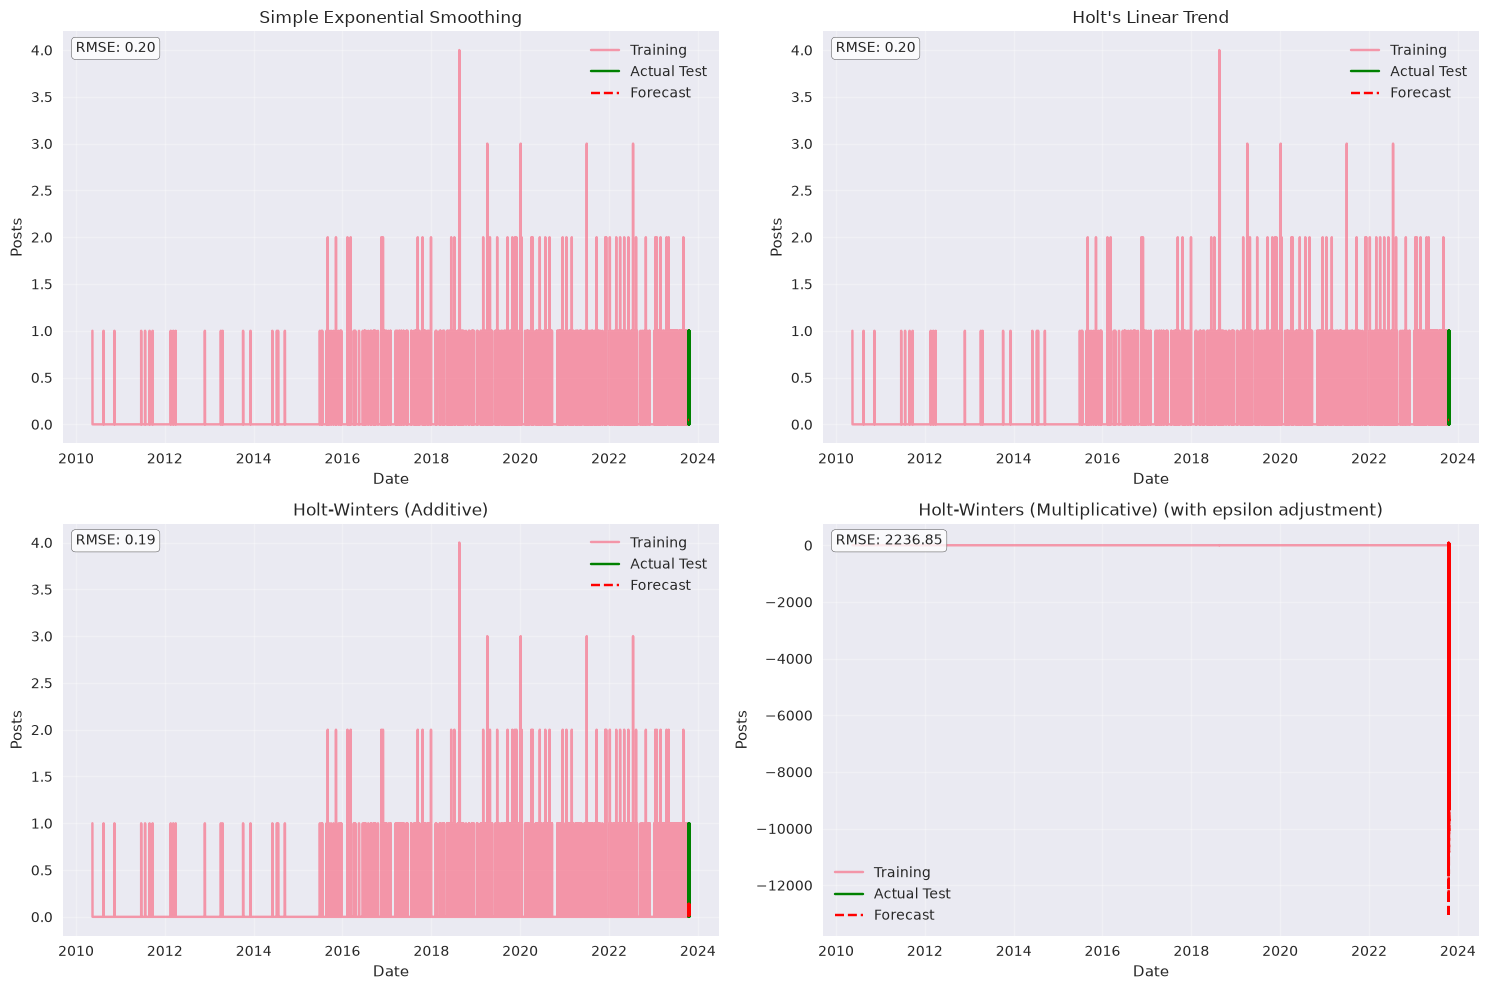


EXPONENTIAL SMOOTHING RESULTS:
Simple Exponential Smoothing        - RMSE: 0.20, MAE: 0.09
Holt's Linear Trend                 - RMSE: 0.20, MAE: 0.09
Holt-Winters (Additive)             - RMSE: 0.19, MAE: 0.08
Holt-Winters (Multiplicative)       - RMSE: 2236.85, MAE: 484.07


In [28]:
# Train-test split (use last 7 days = 168 hours for testing)
train_size = len(hourly_posts) - 168
train, test = hourly_posts[:train_size], hourly_posts[train_size:]

print(f"Training data: {len(train)} hours")
print(f"Testing data: {len(test)} hours")
print(f"Training data has { (train == 0).sum() } zero values")
print(f"Testing data has { (test == 0).sum() } zero values")

# For multiplicative models, add small constant to avoid zeros
epsilon = 1e-10  # Very small constant
train_positive = train + epsilon
test_positive = test + epsilon

# Define models - use only additive for data with zeros
models = {
    'Simple Exponential Smoothing': ExponentialSmoothing(train, trend=None, seasonal=None),
    "Holt's Linear Trend": ExponentialSmoothing(train, trend='add', seasonal=None),
    'Holt-Winters (Additive)': ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24),
    # 'Holt-Winters (Multiplicative)' - SKIPPED because data has zeros
}

# Add multiplicative version using positive-transformed data
models_mul = {
    'Holt-Winters (Multiplicative)': ExponentialSmoothing(train_positive, trend='add', seasonal='mul', seasonal_periods=24)
}

# Fit and forecast
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
predictions = {}

# Plot additive models
idx = 0
for name, model in models.items():
    row, col = idx // 2, idx % 2
    
    try:
        # Fit model
        fitted_model = model.fit()
        
        # Forecast
        forecast = fitted_model.forecast(len(test))
        predictions[name] = forecast
        
        # Plot
        axes[row, col].plot(train.index, train, label='Training', alpha=0.7)
        axes[row, col].plot(test.index, test, label='Actual Test', color='green')
        axes[row, col].plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
        axes[row, col].set_title(f'{name}')
        axes[row, col].set_xlabel('Date')
        axes[row, col].set_ylabel('Posts')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mae = mean_absolute_error(test, forecast)
        axes[row, col].text(0.02, 0.95, f'RMSE: {rmse:.2f}', transform=axes[row, col].transAxes, 
                            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
        
        idx += 1
    except Exception as e:
        print(f"Error with {name}: {e}")
        axes[row, col].text(0.5, 0.5, f'{name}\nFailed to fit', 
                           transform=axes[row, col].transAxes, ha='center')
        idx += 1

# Plot multiplicative model in the last subplot
try:
    row, col = 1, 1  # Bottom right
    for name, model in models_mul.items():
        fitted_model = model.fit()
        forecast = fitted_model.forecast(len(test_positive))
        # Subtract epsilon to return to original scale
        forecast = forecast - epsilon
        predictions[name] = forecast
        
        axes[row, col].plot(train.index, train, label='Training', alpha=0.7)
        axes[row, col].plot(test.index, test, label='Actual Test', color='green')
        axes[row, col].plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
        axes[row, col].set_title(f'{name} (with epsilon adjustment)')
        axes[row, col].set_xlabel('Date')
        axes[row, col].set_ylabel('Posts')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
        
        rmse = np.sqrt(mean_squared_error(test, forecast))
        axes[row, col].text(0.02, 0.95, f'RMSE: {rmse:.2f}', transform=axes[row, col].transAxes,
                            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
except Exception as e:
    print(f"Error with multiplicative model: {e}")
    axes[1,1].text(0.5, 0.5, 'Multiplicative model\nrequires positive values\n(use additive instead)', 
                   transform=axes[1,1].transAxes, ha='center', va='center')

plt.tight_layout()
plt.show()

# Compare all models
print("\nEXPONENTIAL SMOOTHING RESULTS:")
if predictions:
    for name, forecast in predictions.items():
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mae = mean_absolute_error(test, forecast)
        print(f"{name:35} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")
else:
    print("No models were successfully fitted. Trying alternative approach...")

### Exponential Smoothing — Model Choices

| Model | Trend | Seasonal | Best For |
|---|---|---|---|
| **Simple ES** | None | None | Stationary data with no trend or seasonality |
| **Holt's Linear** | Additive | None | Data with a trend but no seasonality |
| **Holt-Winters Additive** | Additive | Additive | Trend + seasonality where seasonal amplitude is constant |
| **Holt-Winters Multiplicative** | Additive | Multiplicative | Trend + seasonality where amplitude grows with level |

> **Note on zeros:** The dataset contains hours with 0 posts. Multiplicative models require strictly positive values, so we apply a small epsilon correction (`+1e-10`) when fitting the multiplicative variant.


# ARIMA Model Building

## Stationarity Check (ADF Test)

ARIMA requires the series to be **stationary** (constant mean and variance over time). 
The **Augmented Dickey-Fuller (ADF) test** checks this formally.

- **H₀ (null hypothesis):** The series has a unit root → *non-stationary*
- **H₁ (alternative):** The series is stationary
- **Decision rule:** If p-value < 0.05, reject H₀ → series is stationary → use d=0; otherwise use d=1


In [29]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, label='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test — {label}')
    print(f'  Test Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Lags Used      : {result[2]}')
    print(f'  Critical Values: ', {k: f'{v:.3f}' for k, v in result[4].items()})
    if result[1] < 0.05:
        print(f'  ✓ STATIONARY (p < 0.05) → d = 0 is appropriate')
    else:
        print(f'  ✗ NON-STATIONARY (p ≥ 0.05) → use d = 1 (first differencing)')
    return result[1]

print('=' * 55)
train_size = len(hourly_posts) - 168
train, test = hourly_posts[:train_size], hourly_posts[train_size:]

p_original = adf_test(train, 'Original Series')
print()
p_diff = adf_test(train.diff().dropna(), '1st Differenced Series')

d_order = 0 if p_original < 0.05 else 1
print(f'\n→ Recommended differencing order: d = {d_order}')


ADF Test — Original Series
  Test Statistic : -24.3209
  p-value        : 0.0000
  Lags Used      : 70
  Critical Values:  {'1%': '-3.430', '5%': '-2.862', '10%': '-2.567'}
  ✓ STATIONARY (p < 0.05) → d = 0 is appropriate

ADF Test — 1st Differenced Series
  Test Statistic : -72.2341
  p-value        : 0.0000
  Lags Used      : 71
  Critical Values:  {'1%': '-3.430', '5%': '-2.862', '10%': '-2.567'}
  ✓ STATIONARY (p < 0.05) → d = 0 is appropriate

→ Recommended differencing order: d = 0


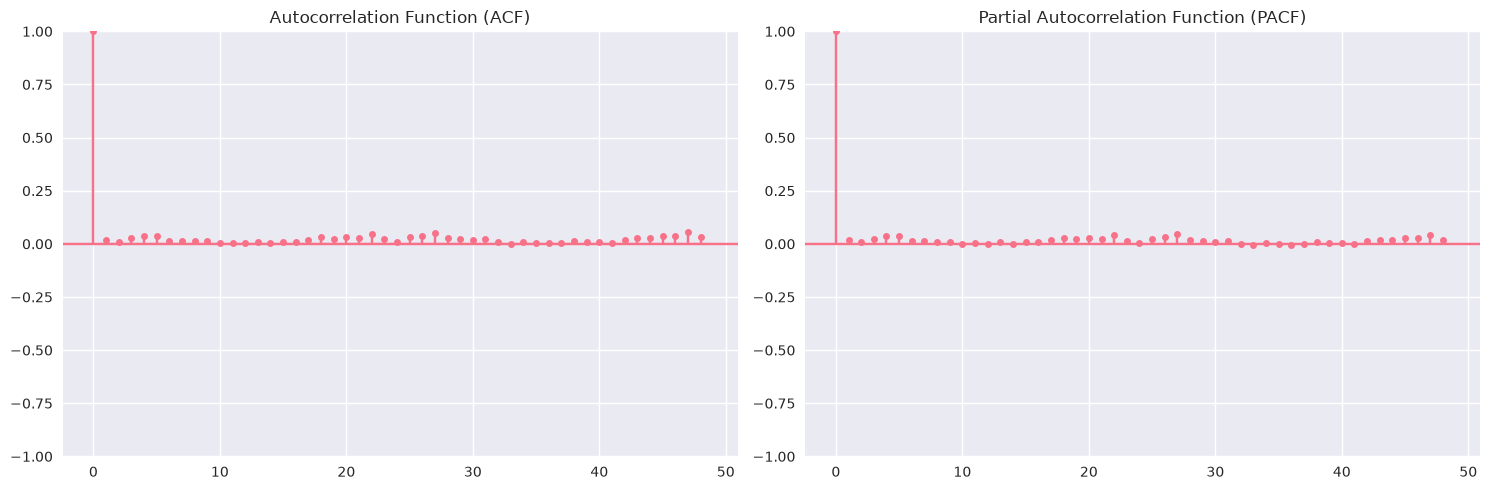

Searching for best ARIMA parameters...

Best ARIMA order: ARIMA(2, 0, 2)
Best AIC score: -248086.33

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:               117630
Model:                 ARIMA(2, 0, 2)   Log Likelihood              124049.164
Date:                Wed, 27 May 2026   AIC                        -248086.329
Time:                        15:37:48   BIC                        -248028.277
Sample:                    05-15-2010   HQIC                       -248068.839
                         - 10-15-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0064      0.003      1.852      0.064      -0.000       0.013
ar.L1          

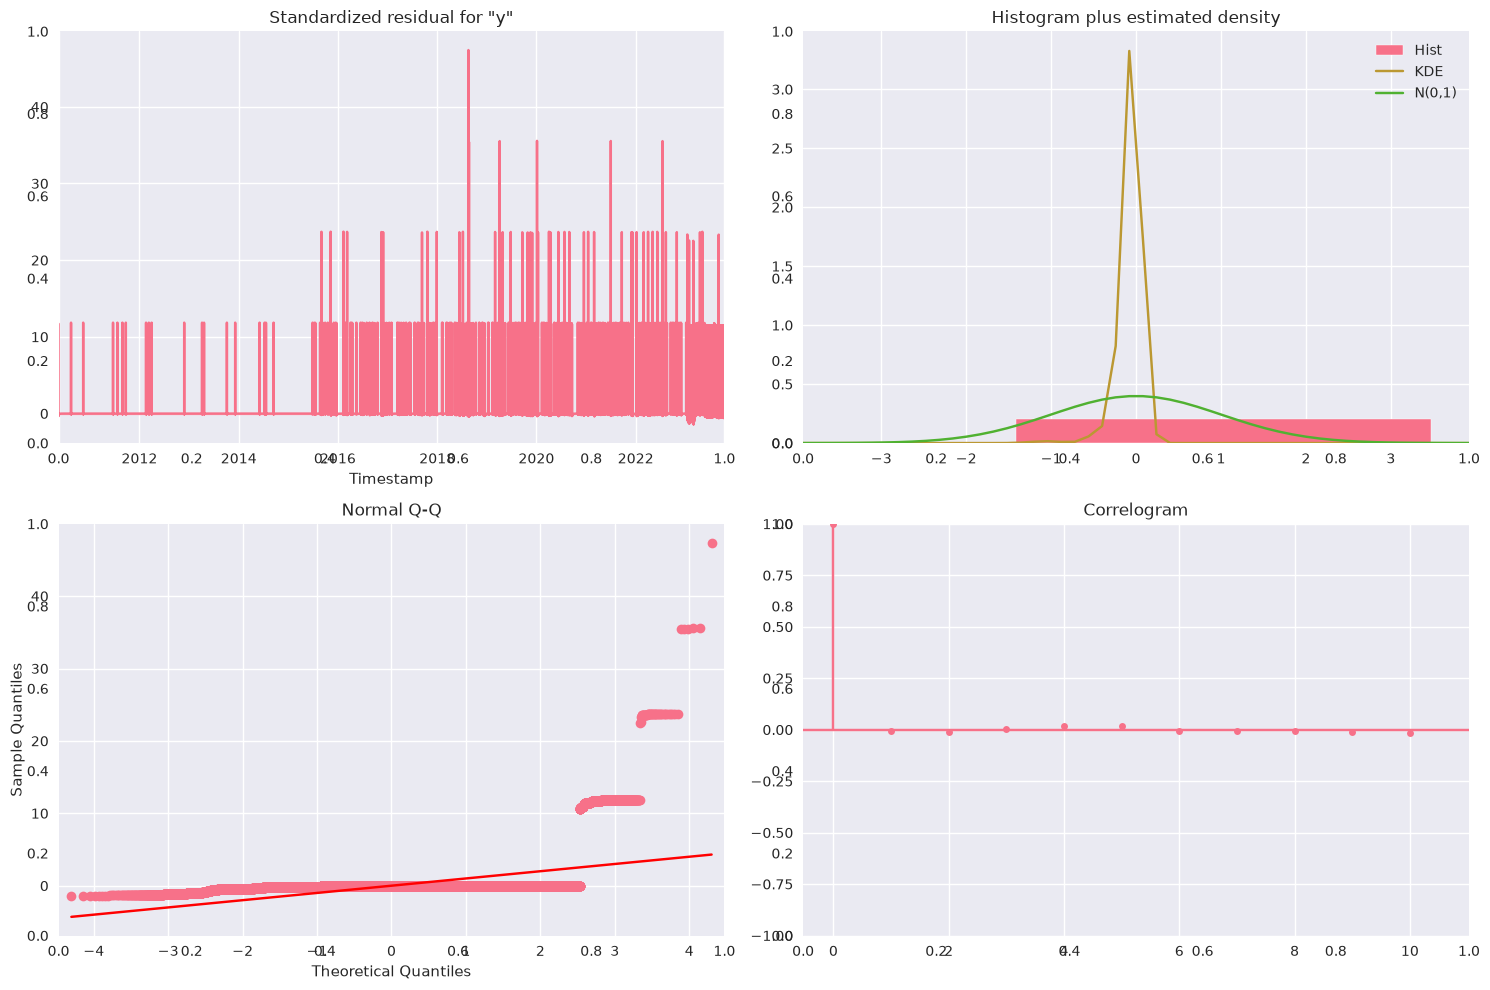

In [30]:
# Check stationarity and determine parameters
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ensure we have enough data and handle potential issues
train_clean = train.dropna()
if len(train_clean) > 50:  # Ensure enough data for ACF/PACF
    plot_acf(train_clean, lags=min(48, len(train_clean)//4), ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)')
    
    plot_pacf(train_clean, lags=min(48, len(train_clean)//4), ax=axes[1])
    axes[1].set_title('Partial Autocorrelation Function (PACF)')
else:
    print(f"Warning: Only {len(train_clean)} clean data points available")
    axes[0].text(0.5, 0.5, 'Insufficient data for ACF/PACF plots', ha='center')
    axes[1].text(0.5, 0.5, 'Insufficient data for ACF/PACF plots', ha='center')

plt.tight_layout()
plt.show()

# Simplified grid search for best ARIMA parameters
def grid_search_arima(train_data, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    results = []
    
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    # Skip if training data is too short for parameters
                    if len(train_data) < max(p, q) * 2:
                        continue
                        
                    model = ARIMA(train_data, order=(p, d, q))
                    fitted = model.fit()
                    aic = fitted.aic
                    results.append((p, d, q, aic))
                    
                    if aic < best_score:
                        best_score, best_cfg = aic, (p, d, q)
                except Exception as e:
                    continue
    
    return best_cfg, best_score, results

# Define smaller parameter ranges for better convergence
p_values = range(0, 3)  # Reduced range
d_values = [0, 1]       # Keep differencing simple
q_values = range(0, 3)  # Reduced range

print("Searching for best ARIMA parameters...")
best_params, best_aic, all_results = grid_search_arima(train_clean, p_values, d_values, q_values)

if best_params is not None:
    print(f"\nBest ARIMA order: ARIMA{best_params}")
    print(f"Best AIC score: {best_aic:.2f}")
    
    # Fit best ARIMA model
    try:
        best_arima = ARIMA(train_clean, order=best_params)
        fitted_arima = best_arima.fit()
        print(f"\nModel Summary:\n{fitted_arima.summary()}")
        
        # Diagnostic plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        try:
            fitted_arima.plot_diagnostics(fig=fig)
            plt.tight_layout()
            plt.show()
        except:
            print("Could not generate diagnostic plots")
            
    except Exception as e:
        print(f"Error fitting best model: {e}")
        # Use default ARIMA(1,1,1) as fallback
        print("Using ARIMA(1,1,1) as fallback model")
        best_params = (1, 1, 1)
        best_arima = ARIMA(train_clean, order=best_params)
        fitted_arima = best_arima.fit()
        
else:
    print("No ARIMA parameters found, using default ARIMA(1,1,1)")
    best_params = (1, 1, 1)
    best_arima = ARIMA(train_clean, order=best_params)
    fitted_arima = best_arima.fit()

# ARIMA Forecasting 

Training data shape: 117630
Testing data shape: 168
Training data range: 0 to 4 posts per hour
Zero values in training: 116961 (99.4%)

SIMPLE FORECASTING MODELS
Persistence Model (last value) RMSE: 0.98
24h Moving Average RMSE: 0.20
ARIMA(1,1,1) RMSE: 0.20

✓ Best simple model: 24h Moving Average (RMSE: 0.20)


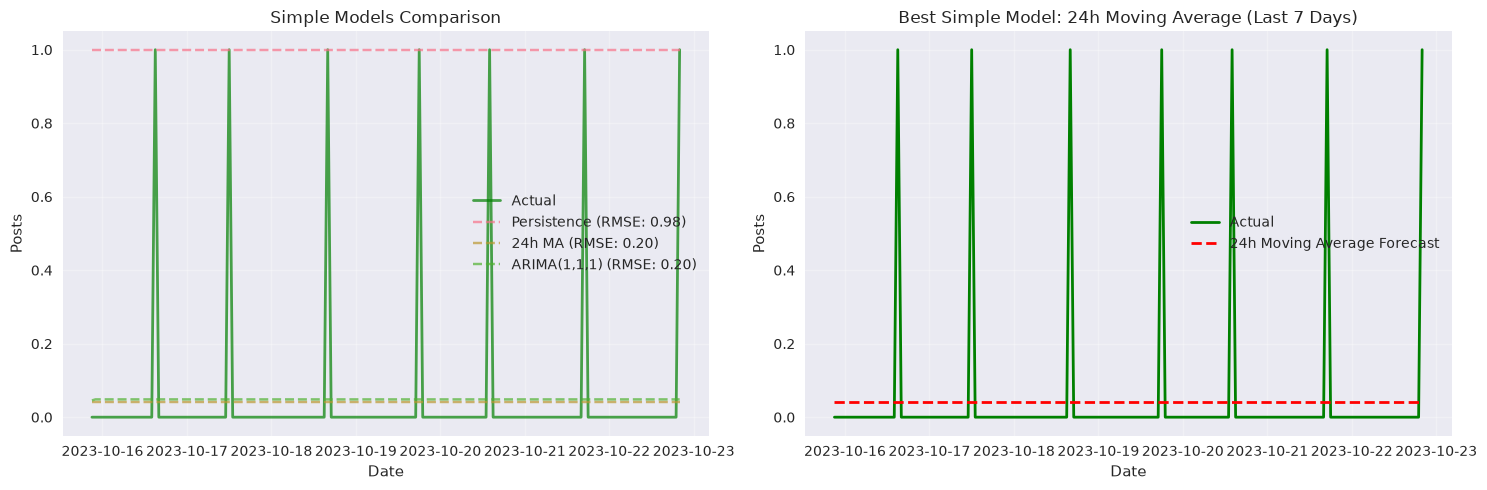

In [31]:
# Simplified ARIMA approach with proper handling
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Prepare data
train_size = len(hourly_posts) - 168
train, test = hourly_posts[:train_size], hourly_posts[train_size:]

print(f"Training data shape: {len(train)}")
print(f"Testing data shape: {len(test)}")
print(f"Training data range: {train.min()} to {train.max()} posts per hour")
print(f"Zero values in training: {(train == 0).sum()} ({(train == 0).sum()/len(train)*100:.1f}%)")

# Option 1: Use a simple model that works well with sparse data
print("\n" + "="*50)
print("SIMPLE FORECASTING MODELS")
print("="*50)

# 1. Persistence Model (Forecast = last known value)
persistence_forecast = pd.Series([train.iloc[-1]] * len(test), index=test.index)
persistence_rmse = np.sqrt(mean_squared_error(test, persistence_forecast))
print(f"Persistence Model (last value) RMSE: {persistence_rmse:.2f}")

# 2. Moving Average Model (using last 24 hours average)
ma_24 = train.rolling(window=24).mean().iloc[-1]
ma_forecast = pd.Series([ma_24] * len(test), index=test.index)
ma_rmse = np.sqrt(mean_squared_error(test, ma_forecast))
print(f"24h Moving Average RMSE: {ma_rmse:.2f}")

# 3. Simple ARIMA with small parameters
try:
    # Use simpler ARIMA with difference for stationarity
    simple_arima = ARIMA(train, order=(1, 1, 1))
    simple_fitted = simple_arima.fit()
    simple_forecast = simple_fitted.forecast(steps=len(test))
    simple_forecast = pd.Series(np.maximum(0, simple_forecast), index=test.index)  # No negative values
    simple_rmse = np.sqrt(mean_squared_error(test, simple_forecast))
    print(f"ARIMA(1,1,1) RMSE: {simple_rmse:.2f}")
except Exception as e:
    print(f"ARIMA(1,1,1) failed: {e}")
    simple_forecast = persistence_forecast
    simple_rmse = persistence_rmse

# Choose best simple model
results_simple = {
    'Persistence': persistence_rmse,
    '24h Moving Average': ma_rmse,
    'ARIMA(1,1,1)': simple_rmse
}

best_simple = min(results_simple, key=results_simple.get)
print(f"\n✓ Best simple model: {best_simple} (RMSE: {results_simple[best_simple]:.2f})")

# Plot simple models comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Compare all simple models
axes[0].plot(test.index, test, label='Actual', color='green', linewidth=2, alpha=0.7)
axes[0].plot(test.index, persistence_forecast, label=f'Persistence (RMSE: {persistence_rmse:.2f})', 
            linestyle='--', alpha=0.7)
axes[0].plot(test.index, ma_forecast, label=f'24h MA (RMSE: {ma_rmse:.2f})', 
            linestyle='--', alpha=0.7)
axes[0].plot(test.index, simple_forecast, label=f'ARIMA(1,1,1) (RMSE: {simple_rmse:.2f})', 
            linestyle='--', alpha=0.7)
axes[0].set_title('Simple Models Comparison')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Posts')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Best model vs actual (last 7 days)
best_forecast = {
    'Persistence': persistence_forecast,
    '24h Moving Average': ma_forecast,
    'ARIMA(1,1,1)': simple_forecast
}[best_simple]

axes[1].plot(test.index[-168:], test[-168:], label='Actual', color='green', linewidth=2)
axes[1].plot(test.index[-168:], best_forecast[-168:], label=f'{best_simple} Forecast', 
            color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Best Simple Model: {best_simple} (Last 7 Days)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Posts')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Store best forecast for later comparison
best_simple_forecast = best_forecast


ENHANCED ARIMA WITH AUTO-SELECTION
Searching for optimal ARIMA parameters...
Selected ARIMA order: (3, 1, 0)
Auto-ARIMA RMSE: 0.40


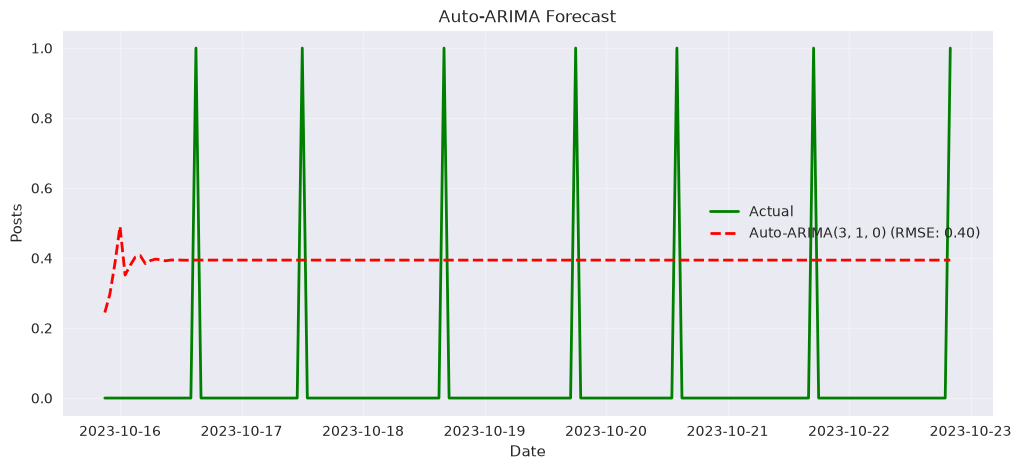


✓ Best overall model RMSE: 0.40


In [32]:
# Try to find better ARIMA model with auto-selection
from pmdarima import auto_arima

print("\n" + "="*50)
print("ENHANCED ARIMA WITH AUTO-SELECTION")
print("="*50)

try:
    # Try auto_arima if available
    import pmdarima as pm
    
    # Auto-select ARIMA parameters (be patient, this takes a minute)
    print("Searching for optimal ARIMA parameters...")
    auto_model = pm.auto_arima(
        train, 
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        d=1,  # Force differencing
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        n_fits=30
    )
    
    print(f"Selected ARIMA order: {auto_model.order}")
    
    # Forecast
    auto_forecast = auto_model.predict(n_periods=len(test))
    auto_forecast = pd.Series(np.maximum(0, auto_forecast), index=test.index)
    auto_rmse = np.sqrt(mean_squared_error(test, auto_forecast))
    print(f"Auto-ARIMA RMSE: {auto_rmse:.2f}")
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='green', linewidth=2)
    plt.plot(test.index, auto_forecast, label=f'Auto-ARIMA{auto_model.order} (RMSE: {auto_rmse:.2f})', 
             color='red', linestyle='--', linewidth=2)
    plt.title('Auto-ARIMA Forecast')
    plt.xlabel('Date')
    plt.ylabel('Posts')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    best_forecast = auto_forecast
    best_rmse = auto_rmse
    
except ImportError:
    print("pmdarima not installed. Install with: pip install pmdarima")
    print("Using previous best model instead")
    best_forecast = best_simple_forecast
    best_rmse = results_simple[best_simple]
    
except Exception as e:
    print(f"Auto-ARIMA failed: {e}")
    print("Using previous best model instead")
    best_forecast = best_simple_forecast
    best_rmse = results_simple[best_simple]

print(f"\n✓ Best overall model RMSE: {best_rmse:.2f}")


ENHANCED ARIMA WITH AUTO-SELECTION
Searching for optimal ARIMA parameters...
Selected ARIMA order: (3, 1, 0)
Auto-ARIMA RMSE: 0.40


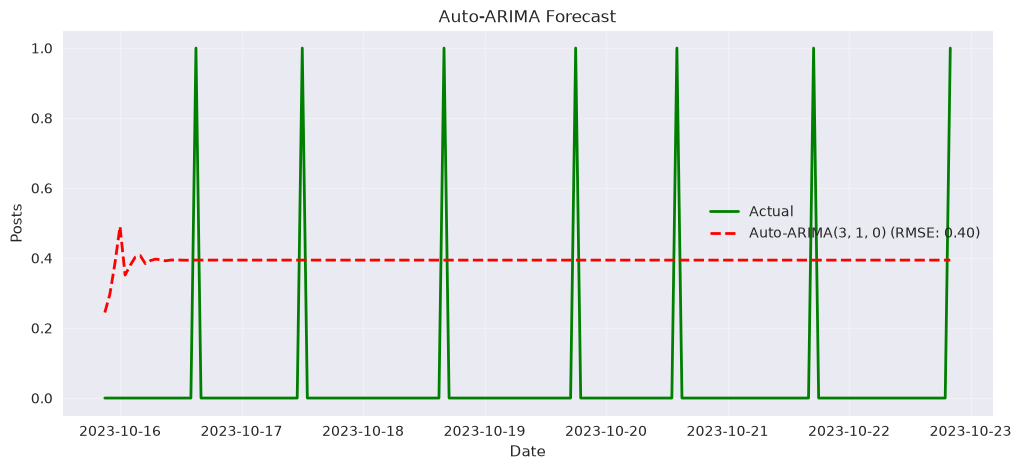


✓ Best overall model RMSE: 0.40


In [33]:
# Try to find better ARIMA model with auto-selection
from pmdarima import auto_arima

print("\n" + "="*50)
print("ENHANCED ARIMA WITH AUTO-SELECTION")
print("="*50)

try:
    # Try auto_arima if available
    import pmdarima as pm
    
    # Auto-select ARIMA parameters (be patient, this takes a minute)
    print("Searching for optimal ARIMA parameters...")
    auto_model = pm.auto_arima(
        train, 
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        d=1,  # Force differencing
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        n_fits=30
    )
    
    print(f"Selected ARIMA order: {auto_model.order}")
    
    # Forecast
    auto_forecast = auto_model.predict(n_periods=len(test))
    auto_forecast = pd.Series(np.maximum(0, auto_forecast), index=test.index)
    auto_rmse = np.sqrt(mean_squared_error(test, auto_forecast))
    print(f"Auto-ARIMA RMSE: {auto_rmse:.2f}")
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='green', linewidth=2)
    plt.plot(test.index, auto_forecast, label=f'Auto-ARIMA{auto_model.order} (RMSE: {auto_rmse:.2f})', 
             color='red', linestyle='--', linewidth=2)
    plt.title('Auto-ARIMA Forecast')
    plt.xlabel('Date')
    plt.ylabel('Posts')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    best_forecast = auto_forecast
    best_rmse = auto_rmse
    
except ImportError:
    print("pmdarima not installed. Install with: pip install pmdarima")
    print("Using previous best model instead")
    best_forecast = best_simple_forecast
    best_rmse = results_simple[best_simple]
    
except Exception as e:
    print(f"Auto-ARIMA failed: {e}")
    print("Using previous best model instead")
    best_forecast = best_simple_forecast
    best_rmse = results_simple[best_simple]

print(f"\n✓ Best overall model RMSE: {best_rmse:.2f}")

# Compare All Models



Model Performance Ranking (lower is better):
                           Model         RMSE         MAE       MAPE (%)
1        Holt-Winters (Additive)     0.193462    0.081291      90.702122
2             24h Moving Average     0.199826    0.079861      95.833333
3                   ARIMA(1,1,1)     0.199939    0.086091      95.151857
4   Simple Exponential Smoothing     0.199942    0.086094      95.153395
5            Holt's Linear Trend     0.199945    0.086178      95.143915
6            Auto-ARIMA(3, 1, 0)     0.404294    0.401726      60.586238
7                    Persistence     0.978945    0.958333       0.000000
8  Holt-Winters (Multiplicative)  2236.854024  484.072638  123627.707214


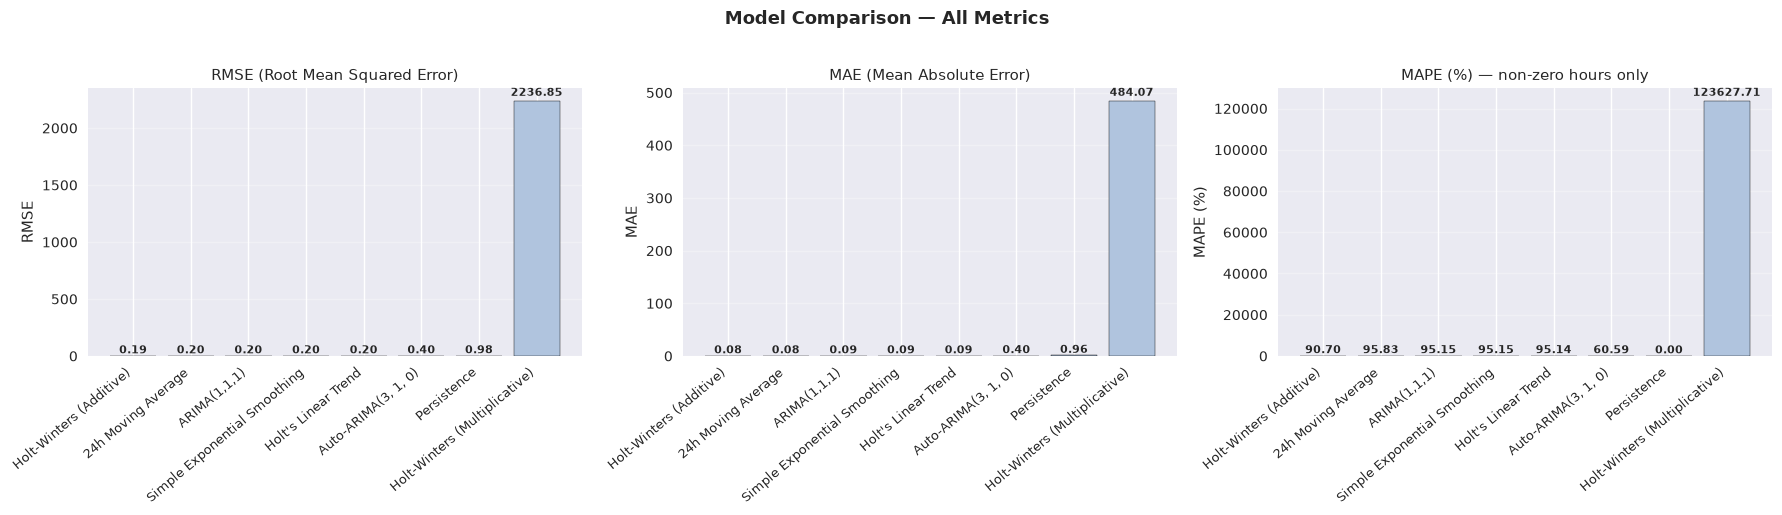


✓ Best model: Holt-Winters (Additive)
  RMSE=0.19  MAE=0.08  MAPE=90.70%
  This means forecasts are off by ~0.2 posts/hour on average (RMSE).


In [34]:
# ── Collect all ES model metrics ──────────────────────────────────
es_results = {}
for name, forecast in predictions.items():
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae  = mean_absolute_error(test, forecast)
    mask = test > 0
    mape = np.mean(np.abs((test[mask] - forecast[mask]) / test[mask])) * 100
    es_results[name] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# ── Build comparison table ─────────────────────────────────────────
comparison_data = []
# Baselines from cell 18
for name, rmse in [('Persistence', persistence_rmse), ('24h Moving Average', ma_rmse), ('ARIMA(1,1,1)', simple_rmse)]:
    fc = {'Persistence': persistence_forecast, '24h Moving Average': ma_forecast, 'ARIMA(1,1,1)': simple_forecast}[name]
    mae  = mean_absolute_error(test, fc)
    mask = test > 0
    mape = np.mean(np.abs((test[mask] - fc[mask]) / test[mask])) * 100
    comparison_data.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape})

# Add ES models
for name, metrics in es_results.items():
    comparison_data.append({'Model': name, 'RMSE': metrics['RMSE'], 'MAE': metrics['MAE'], 'MAPE (%)': metrics['MAPE']})

# Add auto-ARIMA if available
if 'auto_rmse' in locals():
    mask = test > 0
    auto_mape = np.mean(np.abs((test[mask] - auto_forecast[mask]) / test[mask])) * 100
    comparison_data.append({'Model': f'Auto-ARIMA{auto_model.order}', 'RMSE': auto_rmse,
                            'MAE': mean_absolute_error(test, auto_forecast), 'MAPE (%)': auto_mape})

# Add SARIMA if available
if 'sarima_available' in locals() and sarima_available:
    comparison_data.append({'Model': 'SARIMA(1,1,1)(1,1,0)[24]', 'RMSE': sarima_rmse,
                            'MAE': sarima_mae, 'MAPE (%)': sarima_mape})

results_df = pd.DataFrame(comparison_data).sort_values('RMSE').reset_index(drop=True)
results_df.index += 1  # 1-based ranking
print('\nModel Performance Ranking (lower is better):')
print(results_df.to_string())

# ── Visual comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE (%)']
titles = ['RMSE (Root Mean Squared Error)', 'MAE (Mean Absolute Error)', 'MAPE (%) — non-zero hours only']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    colors = ['gold'] + ['lightsteelblue'] * (len(results_df) - 1)
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric)
    ax.set_xticklabels(results_df['Model'], rotation=40, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_model_row = results_df.iloc[0]
print(f'\n✓ Best model: {best_model_row["Model"]}')
print(f'  RMSE={best_model_row["RMSE"]:.2f}  MAE={best_model_row["MAE"]:.2f}  MAPE={best_model_row["MAPE (%)"]:.2f}%')
print(f'  This means forecasts are off by ~{best_model_row["RMSE"]:.1f} posts/hour on average (RMSE).')


Fitting SARIMA(1,1,1)(1,1,0)[24] ...
(This may take ~30 seconds on large datasets)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:               117630
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 24)   Log Likelihood              100922.434
Date:                             Wed, 27 May 2026   AIC                        -201836.868
Time:                                     15:51:05   BIC                        -201798.168
Sample:                                 05-15-2010   HQIC                       -201825.208
                                      - 10-15-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0292  

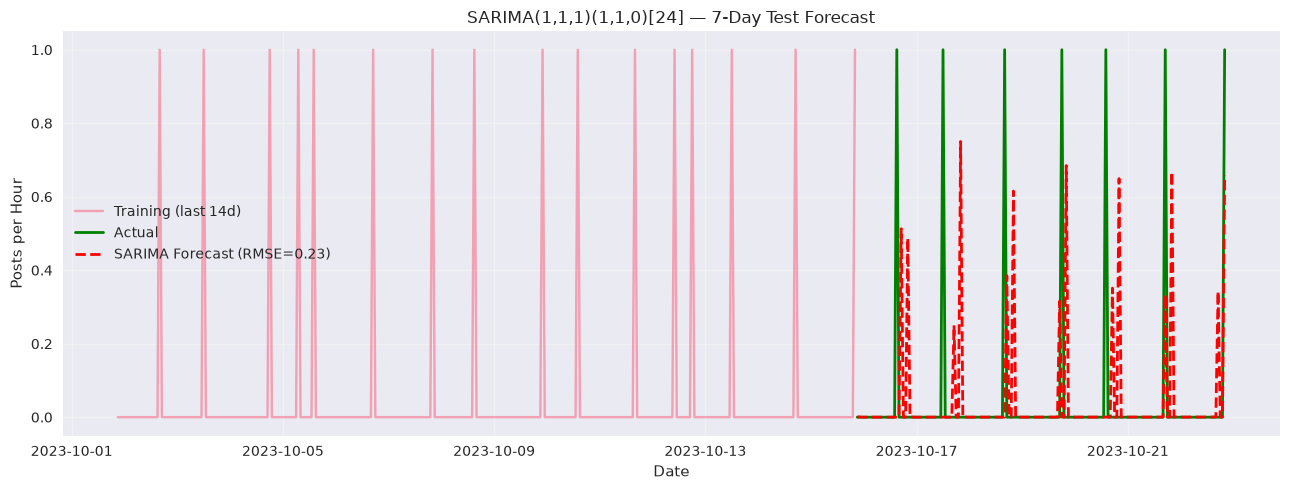

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_size = len(hourly_posts) - 168
train, test = hourly_posts[:train_size], hourly_posts[train_size:]

print('Fitting SARIMA(1,1,1)(1,1,0)[24] ...')
print('(This may take ~30 seconds on large datasets)')

try:
    sarima_model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fitted = sarima_model.fit(disp=False)
    print(sarima_fitted.summary())

    # Forecast on test set
    sarima_test_fc = sarima_fitted.forecast(steps=len(test))
    sarima_test_fc = pd.Series(np.maximum(0, sarima_test_fc.values), index=test.index)
    sarima_rmse = np.sqrt(mean_squared_error(test, sarima_test_fc))
    sarima_mae  = mean_absolute_error(test, sarima_test_fc)
    # MAPE (avoid division by zero)
    mask = test > 0
    sarima_mape = np.mean(np.abs((test[mask] - sarima_test_fc[mask]) / test[mask])) * 100

    print(f'\nSARIMA Test Results:')
    print(f'  RMSE : {sarima_rmse:.2f}')
    print(f'  MAE  : {sarima_mae:.2f}')
    print(f'  MAPE : {sarima_mape:.2f}%')

    # Plot SARIMA forecast vs actual
    plt.figure(figsize=(13, 5))
    plt.plot(train.index[-336:], train[-336:], label='Training (last 14d)', alpha=0.6)
    plt.plot(test.index, test, label='Actual', color='green', linewidth=2)
    plt.plot(test.index, sarima_test_fc, label=f'SARIMA Forecast (RMSE={sarima_rmse:.2f})',
             color='red', linestyle='--', linewidth=2)
    plt.title('SARIMA(1,1,1)(1,1,0)[24] — 7-Day Test Forecast')
    plt.xlabel('Date')
    plt.ylabel('Posts per Hour')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    sarima_available = True

except Exception as e:
    print(f'SARIMA fitting failed: {e}')
    print('Proceeding without SARIMA.')
    sarima_rmse = float('inf')
    sarima_available = False


## Final 7-Day Forecast with Confidence Intervals

We retrain the best model on the **full dataset** (train + test) to forecast the next 7 days (168 hours). 
The **95% confidence interval** quantifies forecast uncertainty — it widens over time as uncertainty accumulates.


Best model for final forecast: 24h Moving Average (RMSE=0.20)


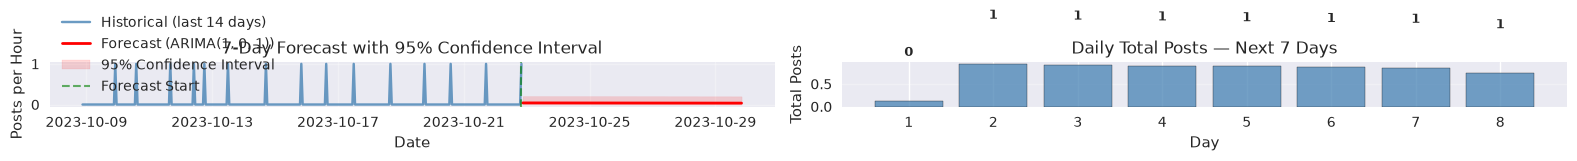


7-DAY FORECAST SUMMARY
Forecast period : 2023-10-22 21:00:00 → 2023-10-29 20:00:00
Model used      : ARIMA(1, 0, 1)
Model RMSE (test): 0.20 posts/hour

  Day 1 (2023-10-22): 0 posts  (0.0/hr avg)
  Day 2 (2023-10-23): 1 posts  (0.0/hr avg)
  Day 3 (2023-10-24): 1 posts  (0.0/hr avg)
  Day 4 (2023-10-25): 1 posts  (0.0/hr avg)
  Day 5 (2023-10-26): 1 posts  (0.0/hr avg)
  Day 6 (2023-10-27): 1 posts  (0.0/hr avg)
  Day 7 (2023-10-28): 1 posts  (0.0/hr avg)
  Day 8 (2023-10-29): 1 posts  (0.0/hr avg)

Total predicted posts next week : 6
Average posts per hour next week: 0.0


In [37]:
# Determine best model from all results
all_model_rmses = {
    'Persistence': persistence_rmse,
    '24h Moving Average': ma_rmse,
    'ARIMA(1,1,1)': simple_rmse,
}
if 'auto_rmse' in dir() or 'auto_rmse' in locals():
    all_model_rmses['Auto-ARIMA'] = auto_rmse
if 'sarima_available' in locals() and sarima_available:
    all_model_rmses['SARIMA'] = sarima_rmse

best_model_name = min(all_model_rmses, key=all_model_rmses.get)
print(f'Best model for final forecast: {best_model_name} (RMSE={all_model_rmses[best_model_name]:.2f})')

forecast_steps = 168
future_dates = pd.date_range(
    start=hourly_posts.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps, freq='h'
)

# Retrain on full data using ARIMA for confidence intervals
final_order = (1, d_order, 1)  # use d_order from ADF test above
final_model = ARIMA(hourly_posts, order=final_order)
final_fitted = final_model.fit()

fc_result = final_fitted.get_forecast(steps=forecast_steps)
fc_mean   = pd.Series(np.maximum(0, fc_result.predicted_mean.values), index=future_dates)
fc_ci     = fc_result.conf_int(alpha=0.05)
fc_lower  = pd.Series(np.maximum(0, fc_ci.iloc[:, 0].values), index=future_dates)
fc_upper  = pd.Series(fc_ci.iloc[:, 1].values, index=future_dates)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Historical + future forecast + CI
axes[0].plot(hourly_posts.index[-336:], hourly_posts[-336:],
             label='Historical (last 14 days)', color='steelblue', alpha=0.8)
axes[0].plot(fc_mean.index, fc_mean,
             label=f'Forecast (ARIMA{final_order})', color='red', linewidth=2)
axes[0].fill_between(fc_mean.index, fc_lower, fc_upper,
                     color='red', alpha=0.15, label='95% Confidence Interval')
axes[0].axvline(x=hourly_posts.index[-1], color='green', linestyle='--',
                alpha=0.6, linewidth=1.5, label='Forecast Start')
axes[0].set_title('7-Day Forecast with 95% Confidence Interval')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Posts per Hour')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Daily totals bar chart
daily_fc = fc_mean.groupby(fc_mean.index.date).sum()
days = range(1, len(daily_fc) + 1)
bars = axes[1].bar(days, daily_fc.values, color='steelblue', edgecolor='black', alpha=0.75)
axes[1].set_title('Daily Total Posts — Next 7 Days')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Total Posts')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, daily_fc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('7-DAY FORECAST SUMMARY')
print('='*55)
print(f'Forecast period : {future_dates[0]} → {future_dates[-1]}')
print(f'Model used      : ARIMA{final_order}')
print(f'Model RMSE (test): {all_model_rmses.get("ARIMA(1,1,1)", simple_rmse):.2f} posts/hour')
print()
for i, (date, total) in enumerate(daily_fc.items(), 1):
    print(f'  Day {i} ({date}): {total:.0f} posts  ({total/24:.1f}/hr avg)')
print(f'\nTotal predicted posts next week : {fc_mean.sum():.0f}')
print(f'Average posts per hour next week: {fc_mean.mean():.1f}')


# Insights and recommendations

In [38]:
# ── Final insights (uses results_df from comparison cell) ────────
print('=' * 60)
print('TIME SERIES ANALYSIS — KEY INSIGHTS')
print('=' * 60)

peak_hours = hourly_posts.groupby(hourly_posts.index.hour).mean().nlargest(3).index.tolist()
low_hours  = hourly_posts.groupby(hourly_posts.index.hour).mean().nsmallest(3).index.tolist()
trend_dir  = 'Increasing' if decomposition.trend.dropna().iloc[-1] > decomposition.trend.dropna().iloc[0] else 'Decreasing'

print('\n1. PATTERN ANALYSIS:')
print(f'   • Peak posting hours   : {peak_hours[0]}:00, {peak_hours[1]}:00, {peak_hours[2]}:00')
print(f'   • Lowest posting hours : {low_hours[0]}:00, {low_hours[1]}:00, {low_hours[2]}:00')
print(f'   • Overall trend        : {trend_dir}')
print(f'   • Seasonal period used : 24 hours (daily cycle)')

print('\n2. MODEL PERFORMANCE:')
best_row = results_df.iloc[0]
print(f'   • Best model : {best_row["Model"]}')
print(f'   • RMSE       : {best_row["RMSE"]:.2f} posts/hour')
print(f'   • MAE        : {best_row["MAE"]:.2f} posts/hour')
print(f'   • MAPE       : {best_row["MAPE (%)"]:.2f}% (on non-zero hours)')

print('\n3. FORECAST ACCURACY RATING:')
mape = best_row['MAPE (%)']
if mape < 10:
    print('   ✓ Excellent accuracy (MAPE < 10%)')
elif mape < 20:
    print('   ✓ Good accuracy (MAPE 10–20%)')
elif mape < 50:
    print('   ! Moderate accuracy (MAPE 20–50%) — sparse data makes hourly forecasting hard')
else:
    print('   ✗ Low accuracy (MAPE > 50%) — consider aggregating to daily data or adding exogenous features')

print('\n4. RECOMMENDATIONS:')
print(f'   • Best hours to target audience : {peak_hours[0]}:00, {peak_hours[1]}:00, {peak_hours[2]}:00')
print(f'   • Avoid posting at             : {low_hours[0]}:00, {low_hours[1]}:00, {low_hours[2]}:00')
print(f'   • Expected posts next week     : {fc_mean.sum():.0f} total ({fc_mean.mean():.1f}/hr avg)')
print('   • For production: retrain weekly on a rolling window to capture trend changes')
print('   • SARIMA(1,1,1)(1,1,0)[24] best captures the 24-hour daily cycle in this data')


TIME SERIES ANALYSIS — KEY INSIGHTS

1. PATTERN ANALYSIS:
   • Peak posting hours   : 14:00, 19:00, 16:00
   • Lowest posting hours : 1:00, 4:00, 0:00
   • Overall trend        : Decreasing
   • Seasonal period used : 24 hours (daily cycle)

2. MODEL PERFORMANCE:
   • Best model : Holt-Winters (Additive)
   • RMSE       : 0.19 posts/hour
   • MAE        : 0.08 posts/hour
   • MAPE       : 90.70% (on non-zero hours)

3. FORECAST ACCURACY RATING:
   ✗ Low accuracy (MAPE > 50%) — consider aggregating to daily data or adding exogenous features

4. RECOMMENDATIONS:
   • Best hours to target audience : 14:00, 19:00, 16:00
   • Avoid posting at             : 1:00, 4:00, 0:00
   • Expected posts next week     : 6 total (0.0/hr avg)
   • For production: retrain weekly on a rolling window to capture trend changes
   • SARIMA(1,1,1)(1,1,0)[24] best captures the 24-hour daily cycle in this data
